In [1]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy
from scipy import stats
import numpy as np
import scipy.stats
%matplotlib inline

In [ ]:
#Load FC mice - both groups
astro_3 = onep.InscopixProcessing(session='fc', animal='astro3', data_directory='/Users/suthardr/Desktop/')
astro_3.read_inscopix()

astro_4 = onep.InscopixProcessing(session='fc', animal='astro4', data_directory='/Users/suthardr/Desktop/')
astro_4.read_inscopix()

astro_5 = onep.InscopixProcessing(session='fc', animal='astro5', data_directory='/Users/suthardr/Desktop/')
astro_5.read_inscopix()
#
astro_6 = onep.InscopixProcessing(session='fc', animal='astro6', data_directory='/Users/suthardr/Desktop/')
astro_6.read_inscopix()

astro_7 = onep.InscopixProcessing(session='fc', animal='astro7', data_directory='/Users/suthardr/Desktop/')
astro_7.read_inscopix()

astro_8 = onep.InscopixProcessing(session='fc', animal='astro8', data_directory='/Users/suthardr/Desktop/')
astro_8.read_inscopix()

astro_9 = onep.InscopixProcessing(session='fc', animal='astro9', data_directory='/Users/suthardr/Desktop/')
astro_9.read_inscopix()


collection_cxta = onep.dCA1Group(astro_3, astro_4, astro_5, astro_6)
collection_cxtb = onep.dCA1Group(astro_7, astro_8, astro_9)
collection_cxta.preprocess()
collection_cxtb.preprocess()

In [2]:
def sequence_heat_plot(unsorted_array, time, ax=None):
    """
    arr: N x T array of cell activity
    time: T array of time
    returns: ax
    """
    # z-score array
    arr = stats.zscore(unsorted_array, axis=1)
    # sort array based on argmax of each row
    arr, _ = onep.maxsort(arr)
    # make a figure
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    # plot the heatmap
    sns.heatmap(arr, cmap='mako',cbar=True, cbar_kws={"label": r"z-scored $\frac{dF}{F}$"})
    # set x-ticks
    ax.set_xticks(np.linspace(0, arr.shape[1], 5), np.linspace(np.min(time), np.max(time), 5))
    # ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.axvline((time.shape[0]/3), linestyle='--', color='white')
    # set labels
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Cells')
    plt.tight_layout()
    return ax, fig

In [6]:
#Save all FC objects as pickle
import pickle
# List of objects to save
astros = [astro_3, astro_4, astro_5, astro_6, astro_7, astro_8, astro_9]  # Add all the astros you want to save to this list

# Loop through each astro and save it
for i, astro in enumerate(astros, start=1):
    filename = f'/Users/suthardr/Desktop/astro{i+2}_fc.pkl'
    with open(filename, 'wb') as filehandler:
        pickle.dump(astro, filehandler)
    print(f'Astro {i+2} saved successfully.')

Astro 3 saved successfully.
Astro 4 saved successfully.
Astro 5 saved successfully.
Astro 6 saved successfully.
Astro 7 saved successfully.
Astro 8 saved successfully.
Astro 9 saved successfully.


In [2]:
import pickle
with open('/Users/suthardr/Desktop/astro4_fc.pkl', 'rb') as filehandler:
    astro_4 = pickle.load(filehandler)
    print(astro_4)

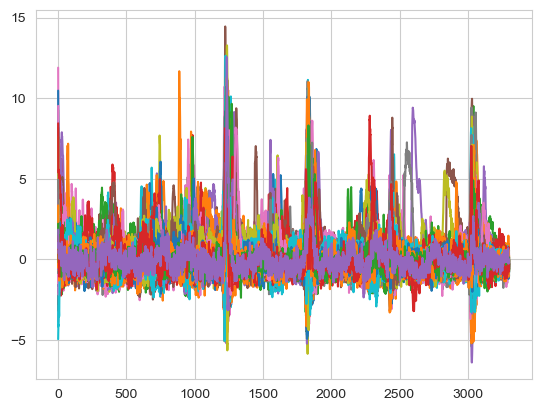

In [16]:
#Run this first
# traces =astro_3.accepted_traces.to_numpy()[:3303]
# traces_z = stats.zscore(traces, axis=0)
# plt.plot(traces_z)
# timestamps = astro_3.Timestamps.to_numpy()[:3303].squeeze()

In [3]:
# make sorted heatmaps for fc at time of shocks - average; z-scored; window=28
for annie in [astro_4]:
    _, whole_eta, time = annie.eta_individual_cells([[120,180,240,300]], window=28)
    sequence_heat_plot(whole_eta, time)
    plt.savefig(f"/Users/suthardr/Desktop/{annie.animal}_sorted_heat_plot_avg.png")

AttributeError: 'DataFrame' object has no attribute 'eta_individual_cells'

In [ ]:
# make_cross_validated plots - FC
for annie in [astro_7, astro_8, astro_9]:
    _, whole_eta_1_3, time_1_3 = annie.eta_individual_cells([[120, 240]], window=28)
    _, whole_eta_2_4, time_2_4 = annie.eta_individual_cells([[180, 300]], window=28)
    # # z_score the data
    whole_eta_1_3 = stats.zscore(whole_eta_1_3, axis=1)
    whole_eta_2_4 = stats.zscore(whole_eta_2_4, axis=1)
    # now get indices for cross validation
    sorted_array_1, idxs_13 = onep.maxsort(whole_eta_1_3)
    sorted_array_2, idxs_24 = onep.maxsort(whole_eta_2_4)
    # now make heat map for cross-validated 2&4 vs. 1&3
    onep.cross_validated_heat_plot(unsorted_array=whole_eta_2_4, idxes_to_sort=idxs_13, sorted_array=sorted_array_1, time=time_1_3)
    plt.savefig(f"/Users/suthardr/Desktop/{annie.animal}_cross_validated_heat_plot.png")

In [23]:
rho, p = stats.spearmanr(whole_eta_1_3, whole_eta_2_4, axis=None)
print("Formatted p-value: {:.20f}".format(p))

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Formatted p-value: 0.00000000000000000000



In [8]:
import pickle
with open('/Users/suthardr/Desktop/astro3_fc.pkl', 'rb') as filehandler:
    astro_3 = pickle.load(filehandler)
    print(astro_3)

In [19]:
#Delete the timestamps row
numpy = np.delete(astro_4.accepted_traces, 1, 0)
numpy

array([[8.71224664e-02, 3.76711932e-02, 1.10896998e-01, ...,
        7.26722378e-03, 7.23011682e-03, 6.71118846e-03],
       [6.84087665e-02, 2.54402661e-02, 7.40408850e-02, ...,
        3.93271136e-03, 5.27631491e-03, 3.87201247e-03],
       [6.36942249e-02, 2.04817152e-02, 6.55095349e-02, ...,
        5.05692470e-03, 4.76011102e-03, 4.65592712e-03],
       ...,
       [4.20272863e-03, 3.12092533e-03, 1.71838083e-03, ...,
        1.16855179e-03, 1.64781425e-03, 4.05018565e-03],
       [3.48079674e-03, 2.74496261e-03, 1.71551833e-03, ...,
        2.50825525e-03, 9.88875090e-04, 2.90270570e-03],
       [2.80445407e-03, 2.72426170e-03, 7.60979679e-05, ...,
        1.63419088e-04, 6.92358397e-04, 4.24920703e-03]])

In [20]:
astro_3.accepted_traces

,C000,C001,C002,C003,C004,C005,C006,C007,C008,C009,...,C174,C175,C177,C178,C179,C180,C181,C182,C184,C185
0.000000,0.087122,0.037671,0.110897,0.057429,0.117138,0.057662,0.083050,0.071345,0.074249,0.054031,...,0.007566,-0.002148,0.025195,0.035885,-0.010828,0.006297,0.009038,0.007267,0.007230,0.006711
0.099923,0.075038,0.029912,0.088512,0.049620,0.107076,0.041592,0.061993,0.065751,0.065766,0.057786,...,0.004772,-0.000418,0.017530,0.030055,-0.009713,0.005174,0.005445,0.004643,0.005620,0.005668
0.199847,0.068409,0.025440,0.074041,0.048216,0.098713,0.036869,0.054498,0.066144,0.058503,0.066950,...,0.004747,-0.002018,0.015320,0.023907,-0.008212,0.004949,0.002952,0.003933,0.005276,0.003872
0.299770,0.063694,0.020482,0.065510,0.048811,0.095013,0.030926,0.050456,0.061667,0.052807,0.075421,...,0.004385,-0.004229,0.014432,0.020133,-0.008433,0.004658,0.000926,0.005057,0.004760,0.004656
0.399693,0.058591,0.017852,0.055582,0.044911,0.091295,0.030924,0.046980,0.059891,0.049970,0.084324,...,0.003591,-0.004565,0.013890,0.018635,-0.006700,0.005393,0.001315,0.004308,0.003368,0.003006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359.424374,0.004903,0.004031,0.001709,0.002706,-0.000573,0.002989,0.000661,0.002034,0.002483,0.003424,...,0.001022,0.000194,0.002577,0.002438,0.000885,0.000400,0.001864,0.001692,0.001413,0.006514
359.524298,0.003942,0.002171,0.001020,0.002218,-0.002353,0.004071,0.001299,0.002514,0.002358,0.003461,...,0.001522,-0.000137,0.003382,0.002144,0.000847,0.001397,0.001943,0.000519,0.002529,0.005642
359.624221,0.004203,0.003121,0.001718,0.002425,-0.001702,0.001718,0.000986,0.002051,0.001615,0.002010,...,0.000551,0.001268,0.003528,-0.000499,0.001351,0.001967,0.002163,0.001169,0.001648,0.004050
359.724144,0.003481,0.002745,0.001716,0.003138,-0.002475,0.001905,0.000008,0.001281,0.000619,0.003233,...,0.001022,0.001307,0.001238,-0.001666,0.001221,0.000535,0.001906,0.002508,0.000989,0.002903


In [9]:
#Concatenate
collection_cxta = onep.dCA1Group(astro_3, astro_4)
# collection_cxtb = onep.dCA1Group(astro_7, astro_8, astro_9)

In [10]:
collection_cxta

In [14]:
collection_cxta.grab_all_traces().T

,0.000000,0.099923,0.199847,0.299770,0.399693,0.499617,0.599540,0.699464,0.799387,0.899310,...,358.925247,359.025170,359.125094,359.225017,359.324941,359.424864,359.524788,359.624711,359.724635,359.824558
0,0.087122,0.075038,0.068409,0.063694,0.058591,0.055122,0.050656,0.046151,0.043935,0.040418,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.037671,0.029912,0.025440,0.020482,0.017852,0.016311,0.015025,0.014740,0.016524,0.015675,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.110897,0.088512,0.074041,0.065510,0.055582,0.048287,0.042287,0.035587,0.029816,0.024574,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.057429,0.049620,0.048216,0.048811,0.044911,0.042824,0.042211,0.043230,0.043078,0.042549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.117138,0.107076,0.098713,0.095013,0.091295,0.085592,0.082603,0.076889,0.071897,0.067316,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,0.009098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001908,0.000852,0.000366,0.001250,0.002449,0.002821,0.001697,0.000563,0.000352,0.000646
436,0.019593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.002715,0.004026,0.006899,0.005310,0.003824,0.005280,0.005226,0.003625,0.003611,0.004172
437,0.027621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001245,0.001337,0.002285,0.002802,0.001175,0.002901,0.002358,0.002119,0.001075,0.002052
438,0.014354,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001140,0.003055,0.002914,0.001532,0.000498,0.001268,0.002428,0.001659,0.001054,0.002227
